# Federated Ensemble Learning for Diabetes Risk Prediction
## 02 - Dataset 2 Exploration

### Purpose
This notebook explores the second diabetes dataset that will be used to train a separate local model.

The goals are to:

- understand the structure and feature groups of Dataset 2,
- assess data quality,
- examine the target variable,
- explore important numerical and categorical variables,
- investigate relationships with diagnosed diabetes,
- identify possible target leakage,
- and decide which variables should be kept or removed before model development.

The target variable for this dataset is `diagnosed_diabetes`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 1. Load Dataset 2


In [2]:
df = pd.read_csv("../data/diabetes_dataset.csv")
df.head()


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


## 2. Dataset Structure


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 100000
Number of columns: 31


In [4]:
df.columns.tolist()


['age',
 'gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diabetes_stage',
 'diagnosed_diabetes']

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

### Initial Observation

Dataset 2 contains **100,000 records and 31 columns**.

It is substantially richer than Dataset 1 and contains demographic, lifestyle,
medical-history, physical-measurement and laboratory variables.

The prediction target is `diagnosed_diabetes`.


## 3. Feature Groups

Grouping the features makes the dataset easier to understand and helps determine
which variables are appropriate for diabetes prediction.


In [6]:
feature_groups = {
    "Demographic": [
        "age", "gender", "ethnicity", "education_level",
        "income_level", "employment_status"
    ],
    "Lifestyle": [
        "smoking_status", "alcohol_consumption_per_week",
        "physical_activity_minutes_per_week", "diet_score",
        "sleep_hours_per_day", "screen_time_hours_per_day"
    ],
    "Medical History": [
        "family_history_diabetes", "hypertension_history",
        "cardiovascular_history"
    ],
    "Physical Measurements": [
        "bmi", "waist_to_hip_ratio", "systolic_bp",
        "diastolic_bp", "heart_rate"
    ],
    "Laboratory Measurements": [
        "cholesterol_total", "hdl_cholesterol", "ldl_cholesterol",
        "triglycerides", "glucose_fasting", "glucose_postprandial",
        "insulin_level", "hba1c"
    ],
    "Diabetes-Related Variables": [
        "diabetes_risk_score", "diabetes_stage", "diagnosed_diabetes"
    ]
}

for group, columns in feature_groups.items():
    print(f"\n{group}:")
    for col in columns:
        print(" -", col)



Demographic:
 - age
 - gender
 - ethnicity
 - education_level
 - income_level
 - employment_status

Lifestyle:
 - smoking_status
 - alcohol_consumption_per_week
 - physical_activity_minutes_per_week
 - diet_score
 - sleep_hours_per_day
 - screen_time_hours_per_day

Medical History:
 - family_history_diabetes
 - hypertension_history
 - cardiovascular_history

Physical Measurements:
 - bmi
 - waist_to_hip_ratio
 - systolic_bp
 - diastolic_bp
 - heart_rate

Laboratory Measurements:
 - cholesterol_total
 - hdl_cholesterol
 - ldl_cholesterol
 - triglycerides
 - glucose_fasting
 - glucose_postprandial
 - insulin_level
 - hba1c

Diabetes-Related Variables:
 - diabetes_risk_score
 - diabetes_stage
 - diagnosed_diabetes


## 4. Descriptive Statistics


In [7]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,50.12041,15.6046,18.0,39.0,50.0,61.0,90.0
gender,100000,3,Female,50216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,100000,5,White,44997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,100000,4,Highschool,44891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_level,100000,5,Middle,35152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,60175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,100000,3,Never,59813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_consumption_per_week,100000.0,NaN,NaN,NaN,2.00367,1.417779,0.0,1.0,2.0,3.0,10.0
physical_activity_minutes_per_week,100000.0,NaN,NaN,NaN,118.91164,84.409662,0.0,57.0,100.0,160.0,833.0
diet_score,100000.0,NaN,NaN,NaN,5.994787,1.780954,0.0,4.8,6.0,7.2,10.0


## 5. Data Quality Assessment

### 5.1 Missing Values


In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing


age                                   0
waist_to_hip_ratio                    0
diabetes_stage                        0
diabetes_risk_score                   0
hba1c                                 0
insulin_level                         0
glucose_postprandial                  0
glucose_fasting                       0
triglycerides                         0
ldl_cholesterol                       0
hdl_cholesterol                       0
cholesterol_total                     0
heart_rate                            0
diastolic_bp                          0
systolic_bp                           0
bmi                                   0
gender                                0
cardiovascular_history                0
hypertension_history                  0
family_history_diabetes               0
screen_time_hours_per_day             0
sleep_hours_per_day                   0
diet_score                            0
physical_activity_minutes_per_week    0
alcohol_consumption_per_week          0


In [9]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


### Observation

No explicit missing values are present in Dataset 2.


### 5.2 Duplicate Records


In [10]:
duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)


Number of exact duplicate rows: 0


### Observation

No exact duplicate rows were identified in Dataset 2.


## 6. Target Variable Analysis

The target variable is `diagnosed_diabetes`.

- `0` = not diagnosed with diabetes
- `1` = diagnosed with diabetes


In [11]:
target_counts = df["diagnosed_diabetes"].value_counts().sort_index()
target_percentages = df["diagnosed_diabetes"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_percentages.round(2))


Counts:
diagnosed_diabetes
0    40002
1    59998
Name: count, dtype: int64

Percentages:
diagnosed_diabetes
0    40.0
1    60.0
Name: proportion, dtype: float64


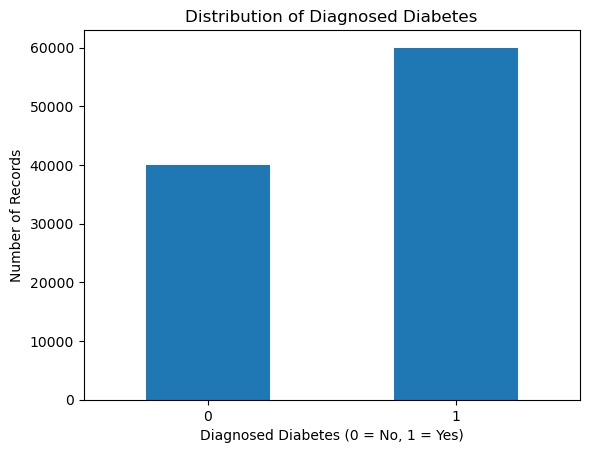

In [12]:
target_counts.plot(kind="bar")

plt.title("Distribution of Diagnosed Diabetes")
plt.xlabel("Diagnosed Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()


### Observation

Dataset 2 is relatively balanced compared with Dataset 1.

Approximately **40% of records are non-diabetic and 60% are diagnosed with diabetes**.
This means severe class imbalance is not expected to be a major issue for Model B.


## 7. Categorical Feature Analysis

The distributions of categorical variables are examined before encoding.


In [13]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns


['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'diabetes_stage']

In [14]:
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())



--- gender ---
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

--- ethnicity ---
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

--- education_level ---
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

--- income_level ---
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

--- employment_status ---
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

--- smoking_status ---
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64

--- diabetes_stage ---
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dty

### Categorical Feature Distributions


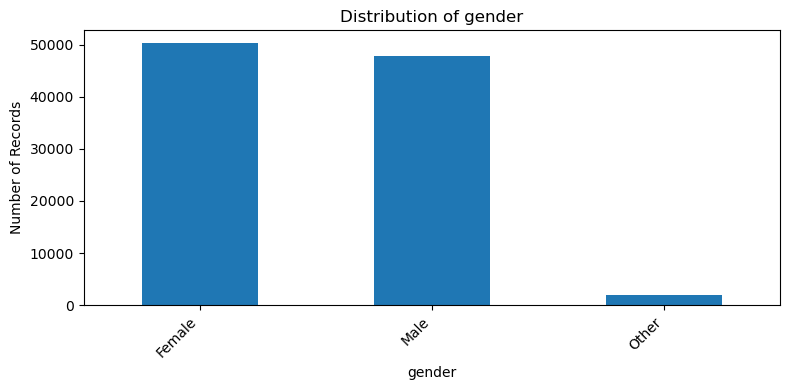

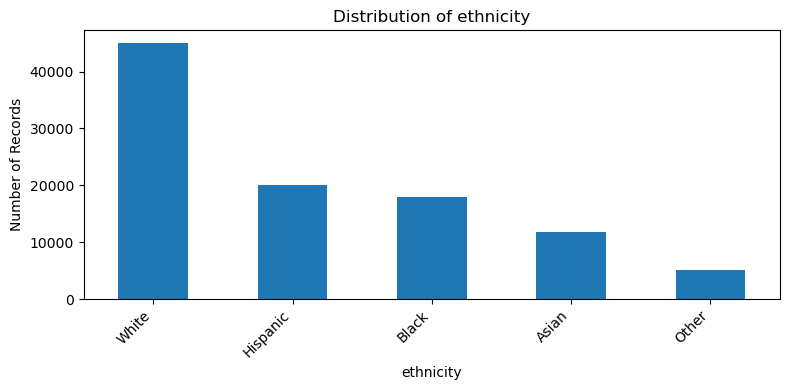

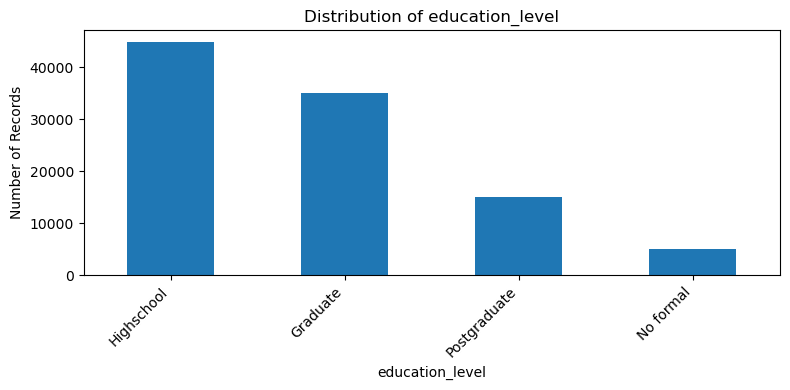

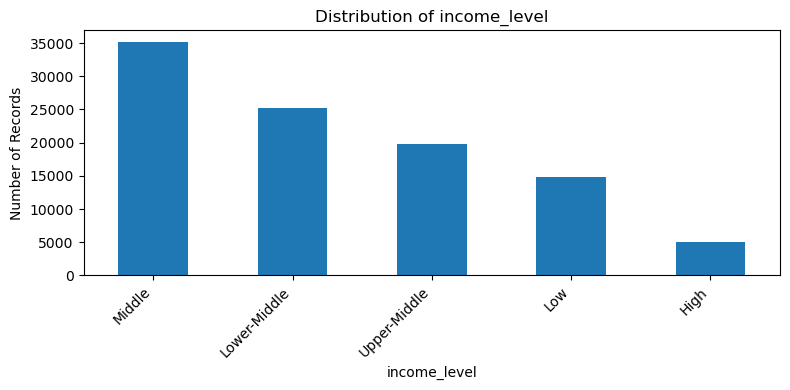

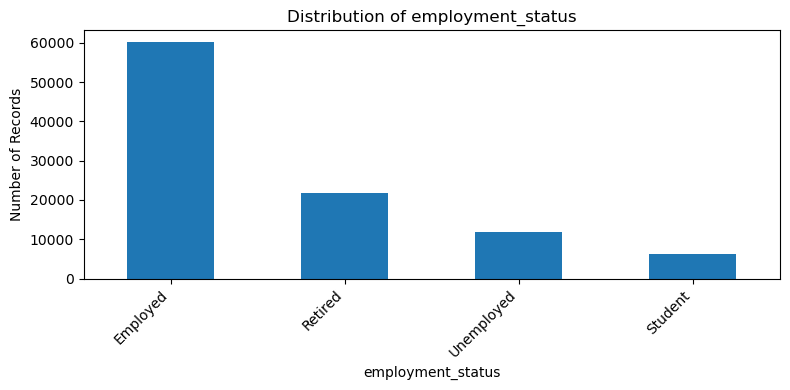

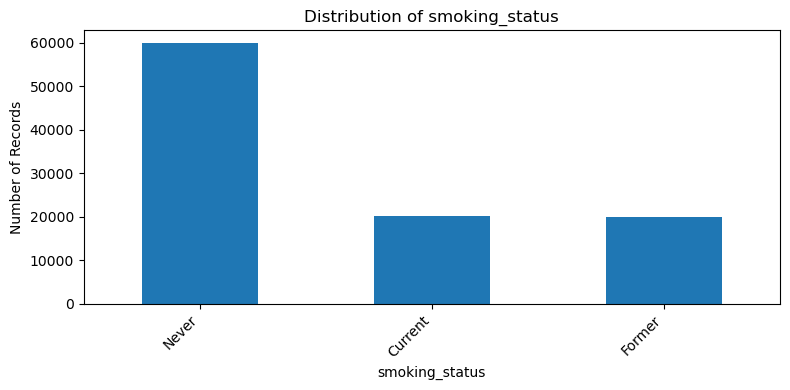

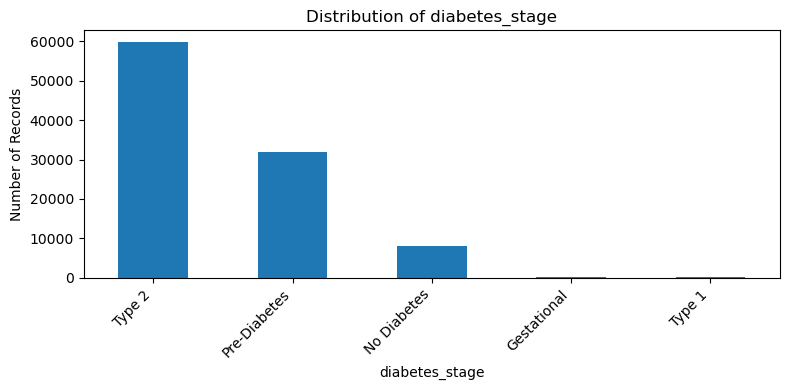

In [15]:
for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    df[column].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 8. Numerical Feature Analysis

Summary statistics are examined for all numerical predictors.


In [16]:
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()
numerical_columns


['age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diagnosed_diabetes']

In [17]:
df[numerical_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


### Selected Numerical Distributions

The following variables are particularly relevant to diabetes prediction and are
examined visually.


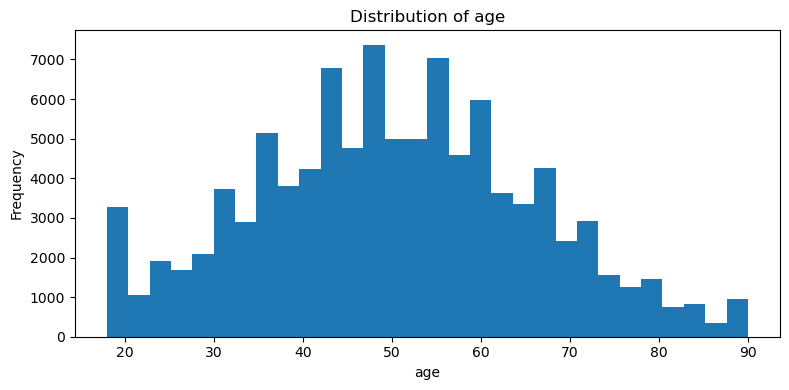

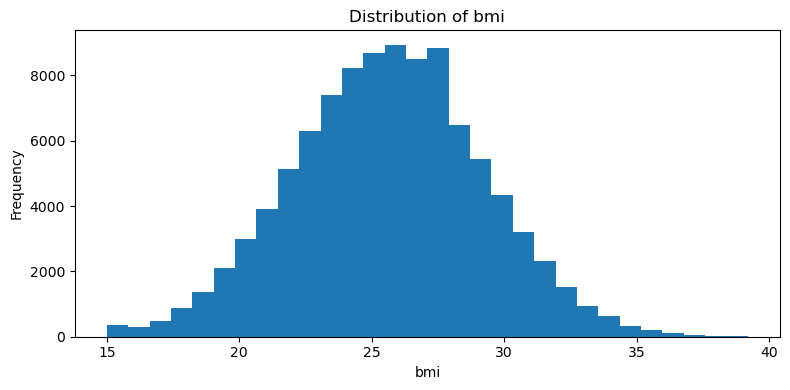

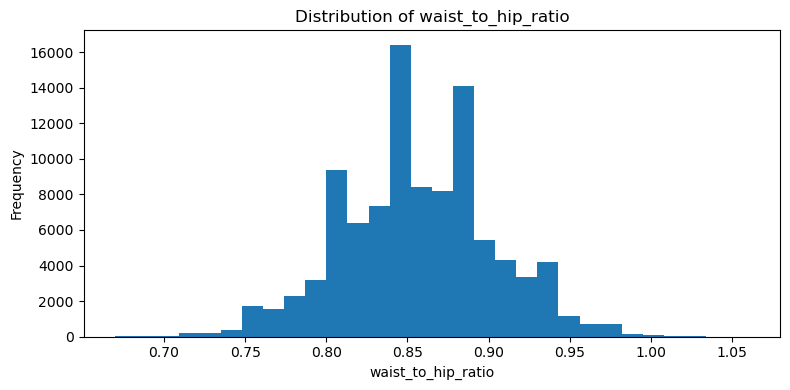

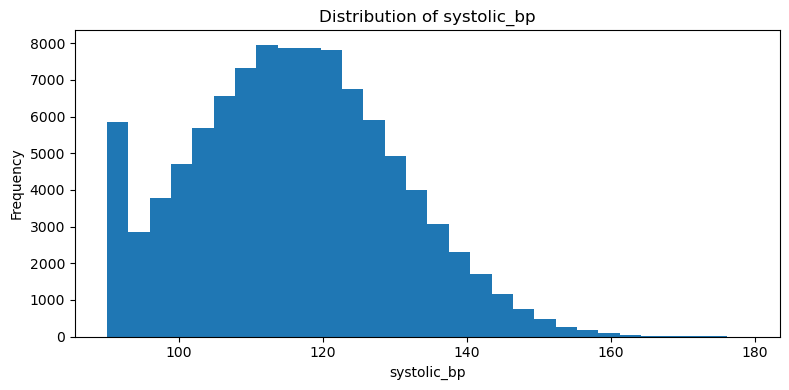

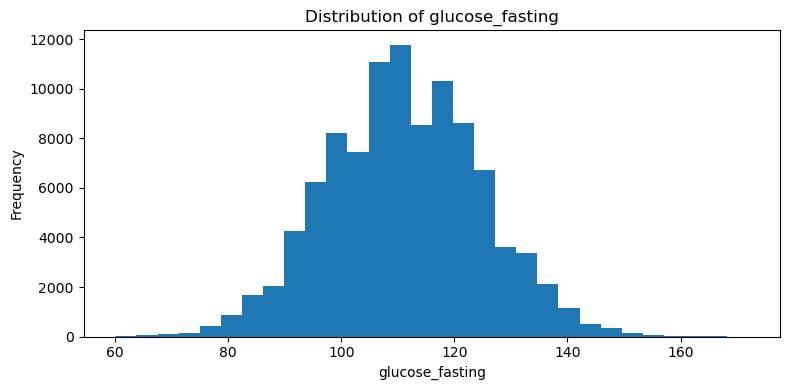

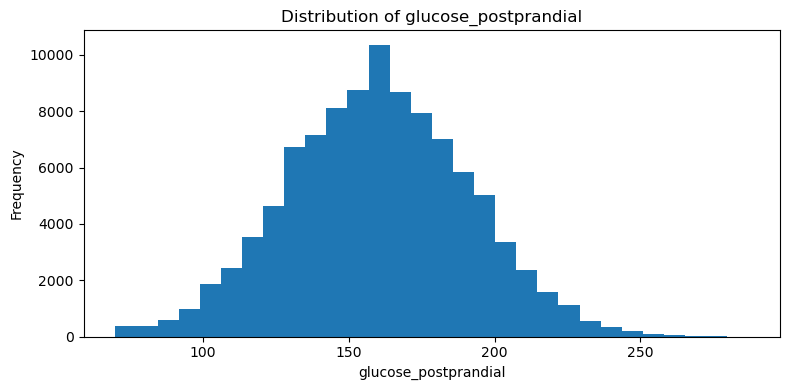

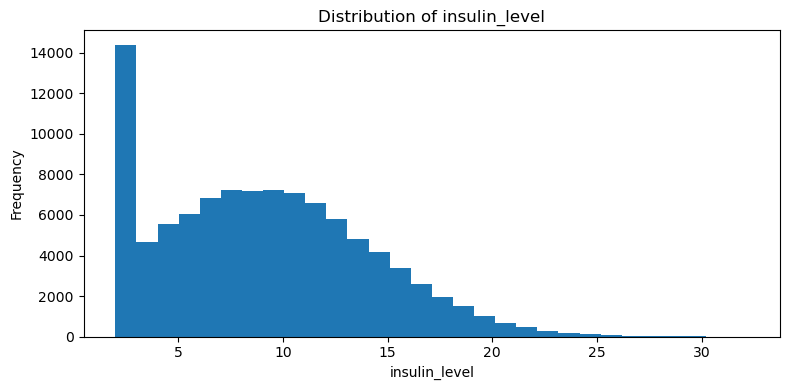

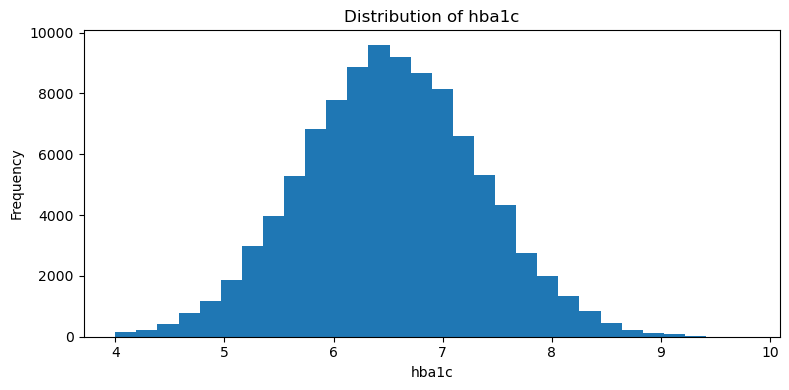

In [18]:
important_numeric = [
    "age",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"
]

for column in important_numeric:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 9. Relationship Between Numerical Features and Diabetes

Average values are compared between the two target classes.


In [19]:
comparison_features = [
    "age",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"
]

df.groupby("diagnosed_diabetes")[comparison_features].mean().T


diagnosed_diabetes,0,1
age,47.488601,51.875096
bmi,25.186321,25.896898
waist_to_hip_ratio,0.851551,0.859096
systolic_bp,114.129319,116.913230
diastolic_bp,74.874606,75.471099
cholesterol_total,183.697365,187.498733
hdl_cholesterol,54.686941,53.613320
ldl_cholesterol,100.241213,104.840061
triglycerides,118.475826,123.454032
glucose_fasting,102.610119,116.788926


## 10. Relationship Between Medical/Lifestyle Features and Diabetes


In [20]:
binary_or_group_features = [
    "family_history_diabetes",
    "hypertension_history",
    "cardiovascular_history",
    "gender",
    "smoking_status",
    "ethnicity"
]

for column in binary_or_group_features:
    print(f"\n--- Diabetes rate by {column} ---")
    table = pd.crosstab(
        df[column],
        df["diagnosed_diabetes"],
        normalize="index"
    ) * 100
    print(table.round(2))



--- Diabetes rate by family_history_diabetes ---
diagnosed_diabetes           0      1
family_history_diabetes              
0                        45.14  54.86
1                        21.71  78.29

--- Diabetes rate by hypertension_history ---
diagnosed_diabetes        0      1
hypertension_history              
0                     40.78  59.22
1                     37.67  62.33

--- Diabetes rate by cardiovascular_history ---
diagnosed_diabetes          0      1
cardiovascular_history              
0                       40.43  59.57
1                       35.03  64.97

--- Diabetes rate by gender ---
diagnosed_diabetes      0      1
gender                          
Female              40.15  59.85
Male                39.93  60.07
Other               37.80  62.20

--- Diabetes rate by smoking_status ---
diagnosed_diabetes      0      1
smoking_status                  
Current             39.99  60.01
Former              39.89  60.11
Never               40.04  59.96

--- Diabe

### Interpretation Note

These tables show associations within the dataset. They should not be interpreted
as evidence that a particular demographic, lifestyle or medical factor causes diabetes.


## 11. Correlation Analysis

Correlation is examined for numerical variables to identify variables that are
most strongly associated with the target.


In [21]:
numeric_df = df.select_dtypes(include=["number"])

correlation_with_target = (
    numeric_df.corr()["diagnosed_diabetes"]
    .sort_values(ascending=False)
)

correlation_with_target


diagnosed_diabetes                    1.000000
hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
diabetes_risk_score                   0.277300
family_history_diabetes               0.197926
age                                   0.137713
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
cholesterol_total                     0.058173
insulin_level                         0.057715
triglycerides                         0.056230
diastolic_bp                          0.035619
cardiovascular_history                0.029793
hypertension_history                  0.027524
heart_rate                            0.022785
screen_time_hours_per_day             0.018127
alcohol_consumption_per_week          0.000760
sleep_hours_per_day                  -0.000399
diet_score   

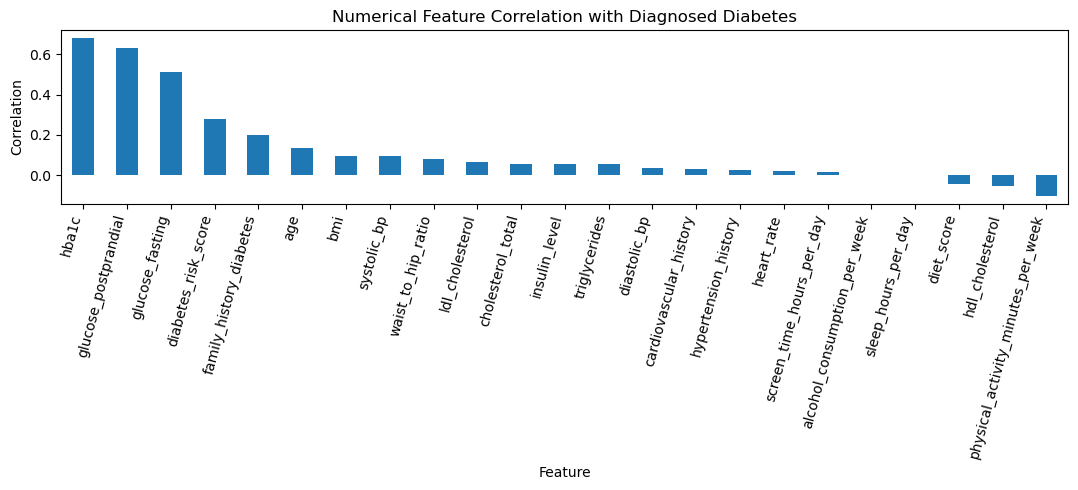

In [22]:
correlation_with_target.drop("diagnosed_diabetes").plot(kind="bar", figsize=(11, 5))

plt.title("Numerical Feature Correlation with Diagnosed Diabetes")
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


### Initial Observation

The strongest numerical associations with `diagnosed_diabetes` should be interpreted
carefully. Strong association can indicate useful predictive information, but it can
also reveal possible target leakage if the variable was calculated using the target
or using information available only after diagnosis.


## 12. Target Leakage Investigation

Two variables require special attention:

- `diabetes_stage`
- `diabetes_risk_score`

`diabetes_stage` directly describes diabetes status/stage and therefore may reveal
the target.

`diabetes_risk_score` may also have been calculated from health variables related
to the prediction task. Its construction should be verified before it is used as
a model input.


In [23]:
stage_target_table = pd.crosstab(
    df["diabetes_stage"],
    df["diagnosed_diabetes"],
    normalize="index"
) * 100

stage_target_table.round(2)


diagnosed_diabetes,0,1
diabetes_stage,,
Gestational,43.17,56.83
No Diabetes,100.00,0.00
Pre-Diabetes,100.00,0.00
Type 1,45.90,54.10
Type 2,0.00,100.00


In [24]:
print(
    "Correlation between diabetes_risk_score and diagnosed_diabetes:",
    round(df["diabetes_risk_score"].corr(df["diagnosed_diabetes"]), 4)
)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Correlation between diabetes_risk_score and diagnosed_diabetes: 0.2773


### Leakage Decision

**`diabetes_stage` should be excluded from the predictor set** because it directly
encodes information about diabetes status and would create substantial target leakage.

**`diabetes_risk_score` should initially be excluded from the predictor set** unless
the dataset documentation clearly demonstrates that it is independently measured
and does not incorporate the target or variables derived after diagnosis.

Keeping these variables could artificially inflate model performance.


## 13. Potential Outlier Assessment

Potential extreme observations are visualised using boxplots. Values should not be
removed automatically because unusual medical measurements may represent genuine
observations.


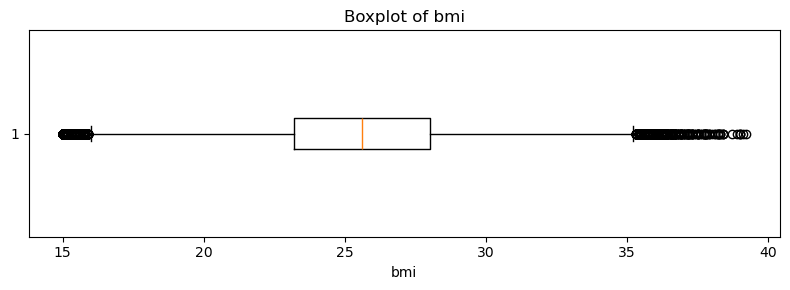

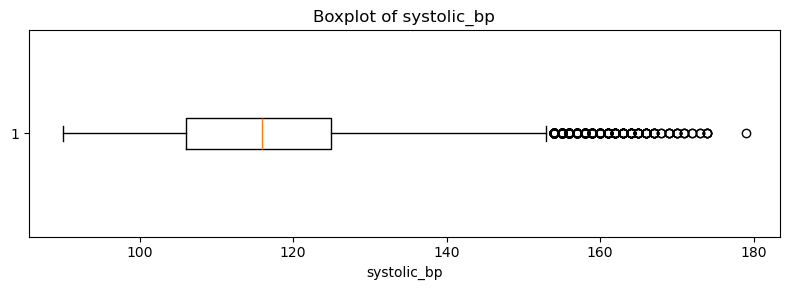

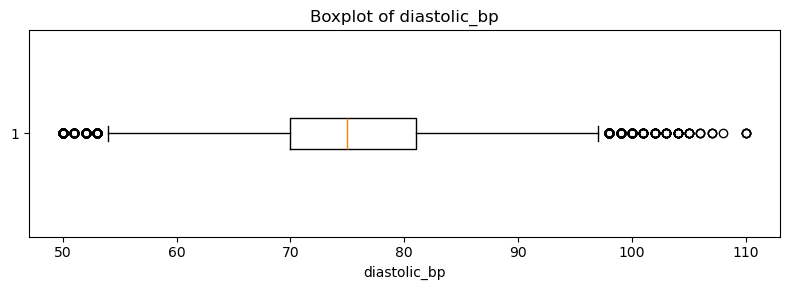

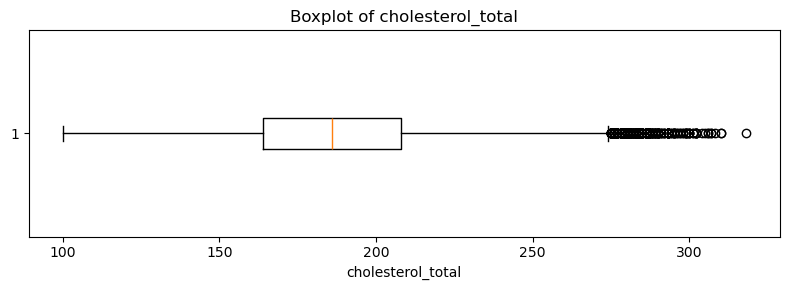

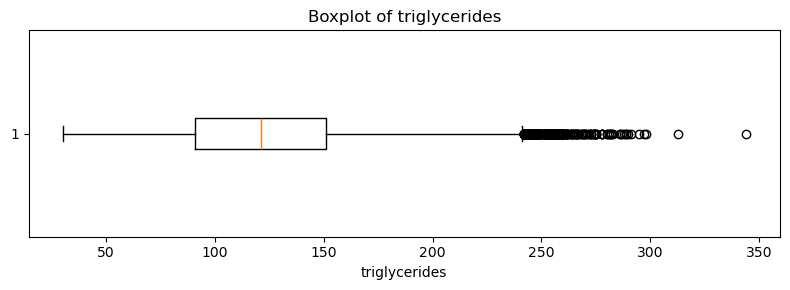

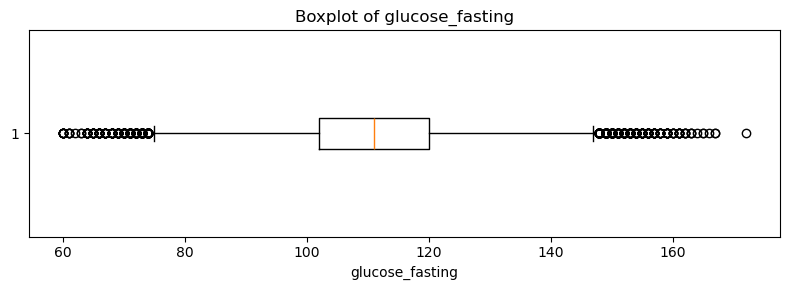

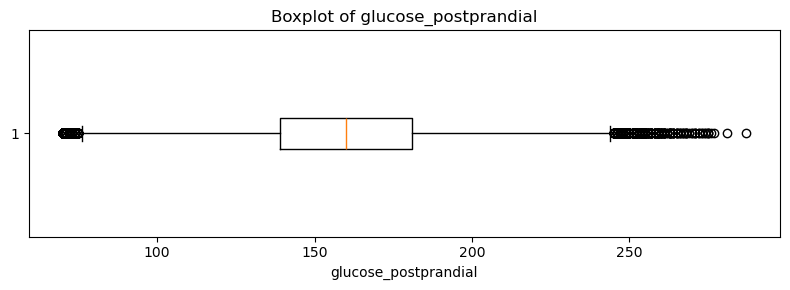

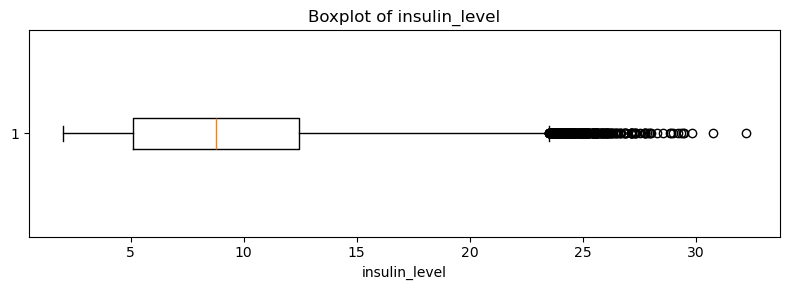

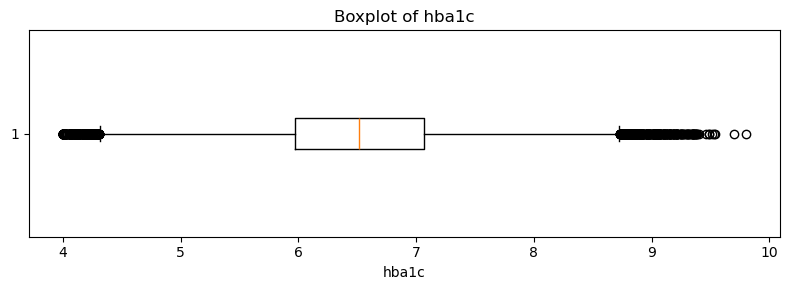

In [25]:
outlier_features = [
    "bmi",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol_total",
    "triglycerides",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"
]

for column in outlier_features:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column], vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()


## 14. Proposed Feature Selection

The table below records the initial decision for each feature.

The aim is to retain as many appropriate features as possible while excluding
variables that could introduce target leakage.


In [26]:
feature_decisions = []

for col in df.columns:
    if col == "diagnosed_diabetes":
        decision = "TARGET"
        reason = "Prediction target."
    elif col == "diabetes_stage":
        decision = "REMOVE"
        reason = "Directly describes diabetes status/stage and creates target leakage."
    elif col == "diabetes_risk_score":
        decision = "INVESTIGATE / REMOVE INITIALLY"
        reason = "Potential derived risk variable; may introduce leakage."
    else:
        decision = "KEEP"
        reason = "Potential demographic, lifestyle, medical, physical or laboratory predictor."

    feature_decisions.append({
        "Feature": col,
        "Decision": decision,
        "Reason": reason
    })

feature_decisions_df = pd.DataFrame(feature_decisions)
feature_decisions_df


,Feature,Decision,Reason
0,age,KEEP,"Potential demographic, lifestyle, medical, phy..."
1,gender,KEEP,"Potential demographic, lifestyle, medical, phy..."
2,ethnicity,KEEP,"Potential demographic, lifestyle, medical, phy..."
3,education_level,KEEP,"Potential demographic, lifestyle, medical, phy..."
4,income_level,KEEP,"Potential demographic, lifestyle, medical, phy..."
5,employment_status,KEEP,"Potential demographic, lifestyle, medical, phy..."
6,smoking_status,KEEP,"Potential demographic, lifestyle, medical, phy..."
7,alcohol_consumption_per_week,KEEP,"Potential demographic, lifestyle, medical, phy..."
8,physical_activity_minutes_per_week,KEEP,"Potential demographic, lifestyle, medical, phy..."
9,diet_score,KEEP,"Potential demographic, lifestyle, medical, phy..."


## 15. Initial Dataset 2 Findings

The exploratory analysis supports the following initial conclusions:

- Dataset 2 contains **100,000 records and 31 columns**.
- It contains a wider range of predictors than Dataset 1, including demographic,
  lifestyle, medical-history, physical and laboratory measurements.
- No explicit missing values or exact duplicate rows were identified.
- The target is relatively balanced, with approximately **40% non-diabetic and
  60% diagnosed-diabetic observations**.
- Clinical measurements such as HbA1c, fasting glucose and postprandial glucose
  are expected to provide substantial predictive information.
- `diabetes_stage` is not appropriate as an input feature because it directly
  describes diabetes status and creates target leakage.
- `diabetes_risk_score` should be excluded initially until its derivation is
  verified.
- All other variables will initially be retained so that Model B can benefit from
  the richer information available in Dataset 2.
- Any potential outliers should be investigated rather than removed automatically.
- Categorical variables will require encoding before model training.

This dataset is suitable for training a separate diabetes prediction model as part
of the federated/ensemble learning experiment.


## 16. Next Steps

The next stage will prepare both diabetes datasets for modelling.

Planned work:

1. Define the final predictor sets for Dataset 1 and Dataset 2.
2. Remove target-leakage variables from Dataset 2.
3. Encode categorical variables.
4. Separate predictors (`X`) and targets (`y`).
5. Create independent training and testing sets for each dataset.
6. Build a baseline model for each dataset.
7. Compare individual model performance.
8. Develop the federated/ensemble aggregation approach.
